# 13 — Tempo de resposta e contribuição preditiva

Esta etapa é uma extensão informada pelos resultados anteriores. Consulte `docs/segunda_etapa_protocolo.md`, registrado no GitHub antes dos testes. Precedência preditiva e associações condicionais não identificam causalidade estrutural.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT/'src'))
from segunda_etapa import *
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize':(12,5),'font.size':11})
pd.set_option('display.max_columns', 20)
def tabela(d):
    display(d.round(5))
def resumo(d):
    tabela(d.groupby(['Família','Período','Categoria resultado']).size().reset_index(name='Modelos'))


## 1. Horizontes definidos antes dos testes
Projeções locais nacionais em1,3,6 e12 meses. Eventos de COBRADE12/13 usam abrangência mensal; seca/estiagem usa soma de protocolos numa janela3. São proxies temporais, sem certificar duração de fenômenos. Desfecho: I(t+h)−I(t), em pontos percentuais. Controlamos o histórico e ΔI(t), pois a resposta começa no mês seguinte. Isso não identifica um choque exógeno.

,Família,Período,Categoria resultado,Modelos
0,RESPOSTA,Pré-pandemia (até jan/2020),Diagnósticos inadequados ou inconclusivos,8
1,RESPOSTA,Total (2013–2024),Diagnósticos inadequados ou inconclusivos,6
2,RESPOSTA,Total (2013–2024),Não significativo,2


,Período,Unidade,Exposição,Janela exposição,Horizonte,Família,Modelo,Transformação,Controles,n efetivo,...,Mês influente,Δ coef influência,Diagnóstico favorável,Limitação,Unidade efeito,Família n,p BH,p BY,p Holm,Categoria resultado
0,Total (2013–2024),Brasil,Súbitos | Municípios,1,1,RESPOSTA,Projeção local associativa,I(t+h)−I(t); Δlog(1+exposição janela),"ΔI0,1,2,3,12; Δexposição1,2,3; 11 dummies; pan...",130,...,2020-05-01,-0.00550,True,Sobreposição induz correlação; HAC não identif...,pp da taxa acumulados por unidade de mudança l...,16,0.992,1.0,1.0,Não significativo
1,Total (2013–2024),Brasil,Súbitos | Municípios,1,3,RESPOSTA,Projeção local associativa,I(t+h)−I(t); Δlog(1+exposição janela),"ΔI0,1,2,3,12; Δexposição1,2,3; 11 dummies; pan...",128,...,2020-04-01,-0.00800,False,Sobreposição induz correlação; HAC não identif...,pp da taxa acumulados por unidade de mudança l...,16,0.992,1.0,1.0,Diagnósticos inadequados ou inconclusivos
2,Total (2013–2024),Brasil,Súbitos | Municípios,1,6,RESPOSTA,Projeção local associativa,I(t+h)−I(t); Δlog(1+exposição janela),"ΔI0,1,2,3,12; Δexposição1,2,3; 11 dummies; pan...",125,...,2020-04-01,-0.01639,False,Sobreposição induz correlação; HAC não identif...,pp da taxa acumulados por unidade de mudança l...,16,0.992,1.0,1.0,Diagnósticos inadequados ou inconclusivos
3,Total (2013–2024),Brasil,Súbitos | Municípios,1,12,RESPOSTA,Projeção local associativa,I(t+h)−I(t); Δlog(1+exposição janela),"ΔI0,1,2,3,12; Δexposição1,2,3; 11 dummies; pan...",119,...,2020-04-01,-0.02052,False,Sobreposição induz correlação; HAC não identif...,pp da taxa acumulados por unidade de mudança l...,16,0.992,1.0,1.0,Diagnósticos inadequados ou inconclusivos
4,Total (2013–2024),Brasil,Seca | Protocolos,3,1,RESPOSTA,Projeção local associativa,I(t+h)−I(t); Δlog(1+exposição janela),"ΔI0,1,2,3,12; Δexposição1,2,3; 11 dummies; pan...",130,...,2020-05-01,0.00384,True,Sobreposição induz correlação; HAC não identif...,pp da taxa acumulados por unidade de mudança l...,16,0.992,1.0,1.0,Não significativo
5,Total (2013–2024),Brasil,Seca | Protocolos,3,3,RESPOSTA,Projeção local associativa,I(t+h)−I(t); Δlog(1+exposição janela),"ΔI0,1,2,3,12; Δexposição1,2,3; 11 dummies; pan...",128,...,2020-04-01,0.00773,False,Sobreposição induz correlação; HAC não identif...,pp da taxa acumulados por unidade de mudança l...,16,0.992,1.0,1.0,Diagnósticos inadequados ou inconclusivos
6,Total (2013–2024),Brasil,Seca | Protocolos,3,6,RESPOSTA,Projeção local associativa,I(t+h)−I(t); Δlog(1+exposição janela),"ΔI0,1,2,3,12; Δexposição1,2,3; 11 dummies; pan...",125,...,2020-04-01,0.01426,False,Sobreposição induz correlação; HAC não identif...,pp da taxa acumulados por unidade de mudança l...,16,0.992,1.0,1.0,Diagnósticos inadequados ou inconclusivos
7,Total (2013–2024),Brasil,Seca | Protocolos,3,12,RESPOSTA,Projeção local associativa,I(t+h)−I(t); Δlog(1+exposição janela),"ΔI0,1,2,3,12; Δexposição1,2,3; 11 dummies; pan...",119,...,2020-03-01,-0.01561,False,Sobreposição induz correlação; HAC não identif...,pp da taxa acumulados por unidade de mudança l...,16,0.992,1.0,1.0,Diagnósticos inadequados ou inconclusivos
8,Pré-pandemia (até jan/2020),Brasil,Súbitos | Municípios,1,1,RESPOSTA,Projeção local associativa,I(t+h)−I(t); Δlog(1+exposição janela),"ΔI0,1,2,3,12; Δexposição1,2,3; 11 dummies; pan...",71,...,2014-08-01,-0.01079,False,Sobreposição induz correlação; HAC não identif...,pp da taxa acumulados por unidade de mudança l...,16,0.992,1.0,1.0,Diagnósticos inadequados ou inconclusivos
9,Pré-pandemia (até jan/2020),Brasil,Súbitos | Municípios,1,3,RESPOSTA,Projeção local associativa,I(t+h)−I(t); Δlog(1+exposição janela),"ΔI0,1,2,3,12; Δexposição1,2,3; 11 dummies; pan...",69,...,2015-08-01,0.00786,False,Sobreposição induz correlação; HAC não identif...,pp da taxa acumulados por unidade de mudança l...,16,0.992,1.0,1.0,Diagnósticos inadequados ou inconclusivos


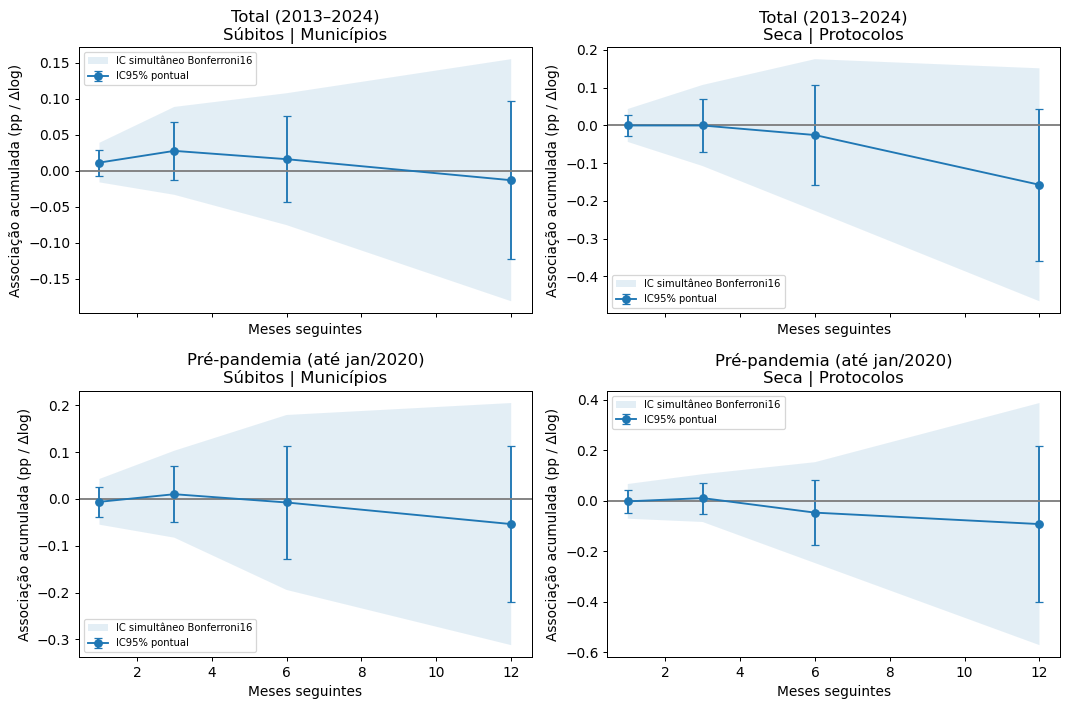

In [2]:
r=response()
resumo(r)
tabela(r)
figura_resposta()

## 2. Incerteza entre horizontes
IC95% pontuais HAC permitem inspecionar estimativas. Bandas Bonferroni16 e p Holm/BH incorporam comparações entre horizontes/períodos/exposições. A sobreposição dos desfechos induz correlação; HAC trata covariância sob pressupostos, sem consertar falta de identificação ou especificação. Os recortes são mantidos, mesmo se os resultados forem inconclusivos.

In [3]:
tabela(r[['Período','Exposição','Horizonte','Coeficiente','IC baixo','IC alto','IC simultâneo baixo','IC simultâneo alto','p','p BH','p Holm','RESET p','CUSUM p','Diagnóstico favorável']])

,Período,Exposição,Horizonte,Coeficiente,IC baixo,IC alto,IC simultâneo baixo,IC simultâneo alto,p,p BH,p Holm,RESET p,CUSUM p,Diagnóstico favorável
0,Total (2013–2024),Súbitos | Municípios,1,0.01137,-0.00669,0.02943,-0.01617,0.03892,0.21463,0.992,1.0,0.30554,0.25261,True
1,Total (2013–2024),Súbitos | Municípios,3,0.02767,-0.01241,0.06775,-0.03348,0.08882,0.17400,0.992,1.0,0.85539,0.01620,False
2,Total (2013–2024),Súbitos | Municípios,6,0.01611,-0.04401,0.07624,-0.07564,0.10786,0.59619,0.992,1.0,0.81946,0.00224,False
3,Total (2013–2024),Súbitos | Municípios,12,-0.01317,-0.12345,0.09710,-0.18159,0.15524,0.81307,0.992,1.0,0.63335,0.00009,False
4,Total (2013–2024),Seca | Protocolos,1,-0.00028,-0.02882,0.02827,-0.04381,0.04326,0.98472,0.992,1.0,0.26144,0.29374,True
5,Total (2013–2024),Seca | Protocolos,3,-0.00036,-0.07073,0.07002,-0.10772,0.10700,0.99200,0.992,1.0,0.83629,0.01578,False
6,Total (2013–2024),Seca | Protocolos,6,-0.02559,-0.15718,0.10600,-0.22640,0.17522,0.70056,0.992,1.0,0.89539,0.00207,False
7,Total (2013–2024),Seca | Protocolos,12,-0.15732,-0.35924,0.04459,-0.46568,0.15104,0.12527,0.992,1.0,0.74088,0.00007,False
8,Pré-pandemia (até jan/2020),Súbitos | Municípios,1,-0.00615,-0.03776,0.02546,-0.05502,0.04272,0.69767,0.992,1.0,0.18487,0.88220,False
9,Pré-pandemia (até jan/2020),Súbitos | Municípios,3,0.01012,-0.04987,0.07011,-0.08274,0.10298,0.73593,0.992,1.0,0.04938,0.41971,False


## 3. Previsão sem divisão aleatória
Janelas expansivas iniciam com72 meses. Em cada origem, o BIC escolhe p no benchmark; o acrescido preserva p e seleciona q no treino. Mesmas datas/controles próprios, sem informação futura na seleção. Somamos ΔI prevista à taxa do mês anterior. Asserções verificam fim do treino antes do alvo. Atlas revisado: exercício pseudo-OOS, sem vintages para certificar disponibilidade operacional.

,Família,Período,Categoria resultado,Modelos
0,PREVISAO,Pré-pandemia (até jan/2020),Excluído / inviável,2
1,PREVISAO,Total (2013–2024),Não significativo,2


,Período,Unidade,Exposição,Família,Modelo,n previsões,Primeiro alvo,Último alvo,RMSE referência,RMSE desastres,...,p descritivo n pequeno,Proporção folds BG favorável,Diagnóstico favorável,Motivo,Unidades,Família n,p BH,p BY,p Holm,Categoria resultado
0,Total (2013–2024),Brasil,Clima | Protocolos,PREVISAO,Expansiva72; AR referência vs ADL; horizonte1,72,2019-01-01,2024-12-01,0.08853,0.08938,...,NaN,1.0,True,"Pseudo-OOS Atlas revisado; modelos aninhados, ...",erros pp; diferencial MSE pp² positivo favorec...,4,0.31822,0.66297,0.58373,Não significativo
1,Total (2013–2024),Brasil,Clima | Municípios,PREVISAO,Expansiva72; AR referência vs ADL; horizonte1,72,2019-01-01,2024-12-01,0.08853,0.08944,...,NaN,1.0,True,"Pseudo-OOS Atlas revisado; modelos aninhados, ...",erros pp; diferencial MSE pp² positivo favorec...,4,0.31822,0.66297,0.58373,Não significativo
2,Pré-pandemia (até jan/2020),Brasil,Clima | Protocolos,PREVISAO,Expansiva72; AR referência vs ADL; horizonte1,13,2019-01-01,2020-01-01,0.06062,0.06415,...,0.02072,1.0,False,"Pseudo-OOS Atlas revisado; modelos aninhados, ...",erros pp; diferencial MSE pp² positivo favorec...,4,1.00000,1.00000,1.00000,Excluído / inviável
3,Pré-pandemia (até jan/2020),Brasil,Clima | Municípios,PREVISAO,Expansiva72; AR referência vs ADL; horizonte1,13,2019-01-01,2020-01-01,0.06062,0.06472,...,0.00639,1.0,False,"Pseudo-OOS Atlas revisado; modelos aninhados, ...",erros pp; diferencial MSE pp² positivo favorec...,4,1.00000,1.00000,1.00000,Excluído / inviável


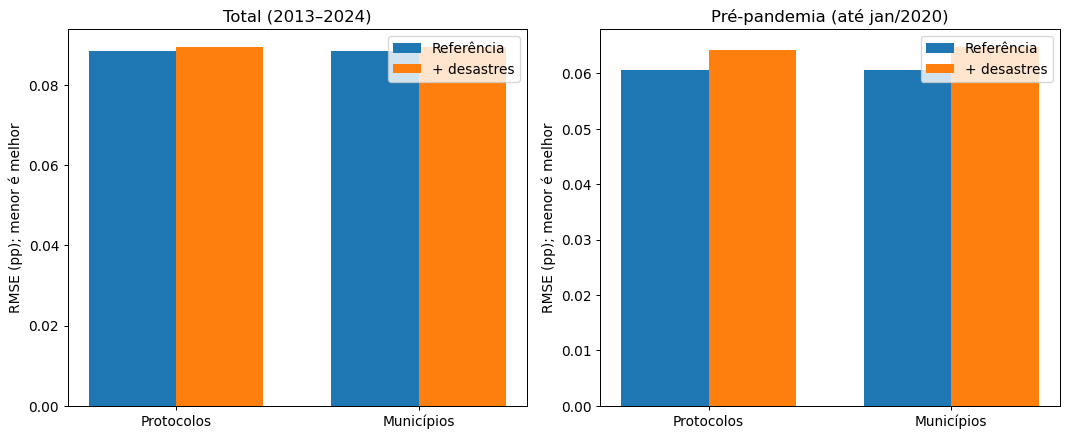

/workspace/scratch/1b453e109626/tcc/src/segunda_etapa.py:354: FutureWarning: acorr_breusch_godfrey currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  dg={'BG1 p':acorr_breusch_godfrey(aug,nlags=1)[1],'BG12 p':acorr_breusch_godfrey(aug,nlags=12)[1]};good.append(dg['BG1 p']>=.05 and dg['BG12 p']>=.05)
/workspace/scratch/1b453e109626/tcc/src/segunda_etapa.py:354: FutureWarning: acorr_breusch_godfrey currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this 

In [4]:
p=prediction()
resumo(p)
tabela(p)
figura_previsao()

## 4. Ganho e limitações
RMSE/MAE em pp: menor é melhor. Diferencial MSE positivo favorece exposição. IC bootstrap em blocos6,1999 repetições, preserva dependência aproximada dos erros; não é bootstrap do teste nacional. Comparação de modelos aninhados é exploratória. Pré possui13 alvos, abaixo do mínimo24 previamente registrado: erros são descritivos e esse cenário não recebe inferência qualificada. Nenhuma simulação de poder é usada para resgatar modelos reprovados.

In [5]:
tabela(read('previsoes_folds'))
tabela(read('disponibilidade_atlas'))
tabela(decisions())
checkpoint('13')

,Período,Exposição,Data alvo,Treino início,Treino fim,n treino,p próprio,q exposição,Observado,Previsão referência,Previsão desastres,Erro referência,Erro desastres,Δ perda MSE,BG1 p,BG12 p
0,Total (2013–2024),Clima | Protocolos,2019-01-01,2013-01-01,2018-12-01,72,1,1,3.47545,3.46619,3.45733,0.00926,0.01812,-0.00024,0.78814,0.18146
1,Total (2013–2024),Clima | Protocolos,2019-02-01,2013-01-01,2019-01-01,73,1,1,3.43434,3.51821,3.52352,-0.08387,-0.08918,-0.00092,0.73808,0.26115
2,Total (2013–2024),Clima | Protocolos,2019-03-01,2013-01-01,2019-02-01,74,1,1,3.50670,3.37460,3.37740,0.13210,0.12929,0.00073,0.75510,0.29124
3,Total (2013–2024),Clima | Protocolos,2019-04-01,2013-01-01,2019-03-01,75,3,1,3.48124,3.54561,3.55147,-0.06437,-0.07023,-0.00079,0.92789,0.26202
4,Total (2013–2024),Clima | Protocolos,2019-05-01,2013-01-01,2019-04-01,76,3,1,3.52826,3.50950,3.49194,0.01876,0.03632,-0.00097,0.88585,0.25864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,Pré-pandemia (até jan/2020),Clima | Municípios,2019-09-01,2013-01-01,2019-08-01,80,3,1,3.64827,3.59637,3.60032,0.05190,0.04795,0.00040,0.93516,0.24554
166,Pré-pandemia (até jan/2020),Clima | Municípios,2019-10-01,2013-01-01,2019-09-01,81,3,1,3.62884,3.68611,3.70830,-0.05727,-0.07946,-0.00303,0.94908,0.21878
167,Pré-pandemia (até jan/2020),Clima | Municípios,2019-11-01,2013-01-01,2019-10-01,82,3,1,3.63080,3.62326,3.60790,0.00754,0.02290,-0.00047,0.90146,0.20519
168,Pré-pandemia (até jan/2020),Clima | Municípios,2019-12-01,2013-01-01,2019-11-01,83,3,1,3.59070,3.52069,3.51995,0.07001,0.07074,-0.00010,0.95151,0.19682


,n,Data registro ausente/inválida,Registro anterior ao evento,Mediana dias,Q90 dias,Q99 dias,Proporção registrado depois mês evento,Limitação
0,40339,0,11,1.0,12.0,77.0,0.1182,Data registro não é vintage de publicação/revi...


,Procedimento,Decisão,Justificativa
0,Bootstrap temporal H0,Não aplicado,Teste condicional à seleção; bootstrap defensá...
1,Simulação de poder,Não aplicada,Não atribuir tamanho/poder confiável a um DGP ...
2,Controles econômicos adicionais,Não incluídos,Não disponíveis na entrada com cobertura ofici...
3,GMM,Não aplicado,"N=27,T longo; evitar proliferação de instrumen..."
